In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##Dataset

In [2]:
people = pd.read_csv("assignment_employee_survey.csv")
people.head()

,emp_id,gender,age,marital_status,job_level,experience,dept,emp_type,wlb,work_env,...,sleep_hours,commute_mode,commute_distance,num_companies,team_size,num_reports,edu_level,have_ot,training_hours_per_year,job_satisfaction
0,6,Male,32,Married,Mid,7,IT,Full-Time,1,1,...,7.6,Car,20,3,12,0,Bachelor,True,33.5,5
1,11,Female,34,Married,Mid,12,Finance,Full-Time,1,1,...,7.9,Car,15,4,11,0,Bachelor,False,36.0,5
2,33,Female,23,Single,Intern/Fresher,1,Marketing,Full-Time,2,4,...,6.5,Motorbike,17,0,30,0,Bachelor,True,10.5,5
3,20,Female,29,Married,Junior,6,IT,Contract,2,2,...,7.5,Public Transport,13,2,9,0,Bachelor,True,23.0,5
4,45,Female,33,Married,Mid,10,Operations,Part-Time,2,3,...,6.2,Car,8,3,13,0,Bachelor,False,35.0,5


##Data Understanding

In [3]:
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2766 entries, 0 to 2765
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   emp_id                   2766 non-null   int64  
 1   gender                   2766 non-null   object 
 2   age                      2766 non-null   int64  
 3   marital_status           2766 non-null   object 
 4   job_level                2766 non-null   object 
 5   experience               2766 non-null   int64  
 6   dept                     2766 non-null   object 
 7   emp_type                 2766 non-null   object 
 8   wlb                      2766 non-null   int64  
 9   work_env                 2766 non-null   int64  
 10  physical_activity_hours  2766 non-null   float64
 11  workload                 2766 non-null   int64  
 12  stress                   2766 non-null   int64  
 13  sleep_hours              2766 non-null   float64
 14  commute_mode            

In [4]:
people.describe()

,emp_id,age,experience,wlb,work_env,physical_activity_hours,workload,stress,sleep_hours,commute_distance,num_companies,team_size,num_reports,training_hours_per_year,job_satisfaction
count,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000
mean,1516.601952,35.650759,8.989154,3.049530,3.028923,2.038250,2.979031,1.737166,7.008351,13.419740,4.223066,16.491685,2.374187,37.220535,3.380694
std,873.996466,10.175719,7.003013,1.448103,1.417494,0.966535,1.405335,1.065303,1.003736,8.344388,3.377586,6.638354,3.055823,13.540622,1.267785
min,1.000000,22.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,4.000000,1.000000,0.000000,5.000000,0.000000,10.000000,1.000000
25%,764.500000,27.000000,3.000000,2.000000,2.000000,1.400000,2.000000,1.000000,6.300000,6.000000,1.000000,11.000000,0.000000,23.500000,3.000000
50%,1515.500000,34.000000,8.000000,3.000000,3.000000,2.100000,3.000000,1.000000,7.000000,13.000000,4.000000,16.000000,0.000000,39.500000,4.000000
75%,2271.750000,43.000000,14.000000,4.000000,4.000000,2.700000,4.000000,2.000000,7.700000,20.000000,7.000000,22.000000,5.000000,46.500000,4.000000
max,3025.000000,60.000000,29.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,29.000000,12.000000,30.000000,9.000000,64.500000,5.000000


In [5]:
people.isnull().sum()

,0
emp_id,0
gender,0
age,0
marital_status,0
job_level,0
experience,0
dept,0
emp_type,0
wlb,0
work_env,0


In [6]:
people.duplicated().sum()

np.int64(0)

##Analisis faktor

In [7]:
satisfaction_people = people[['emp_id','age','marital_status','experience','dept','wlb','work_env','physical_activity_hours','workload','stress','sleep_hours','edu_level','training_hours_per_year','job_satisfaction']]
satisfaction_people.head()

,emp_id,age,marital_status,experience,dept,wlb,work_env,physical_activity_hours,workload,stress,sleep_hours,edu_level,training_hours_per_year,job_satisfaction
0,6,32,Married,7,IT,1,1,2.5,2,1,7.6,Bachelor,33.5,5
1,11,34,Married,12,Finance,1,1,1.8,2,2,7.9,Bachelor,36.0,5
2,33,23,Single,1,Marketing,2,4,2.1,5,4,6.5,Bachelor,10.5,5
3,20,29,Married,6,IT,2,2,1.9,3,1,7.5,Bachelor,23.0,5
4,45,33,Married,10,Operations,2,3,1.4,4,2,6.2,Bachelor,35.0,5


In [8]:
#Rata-rata satisfaction
rata_rata_satisfaction = satisfaction_people['job_satisfaction'].mean().round(2)
print(f'rata-rata satisfaction: {rata_rata_satisfaction}')

rata-rata satisfaction: 3.38


In [9]:
#Nilai maksimal satisfaction
max_satisfaction = satisfaction_people['job_satisfaction'].max()
print(f'nilai maksimal satisfaction: {max_satisfaction}')


nilai maksimal satisfaction: 5


In [10]:
#kepuasan rata-rata perdepatment
kepuasan_dept = satisfaction_people.groupby('dept')['job_satisfaction'].mean().sort_values(ascending=False)
kepuasan_dept


,job_satisfaction
dept,
Sales,3.476923
Operations,3.460976
Finance,3.423009
HR,3.400000
Legal,3.381526
Marketing,3.342466
Customer Service,3.335766
IT,3.287690


In [11]:
#identifikasi segment diatas/dibawah rata-rata
hasil = kepuasan_dept.reset_index()
hasil.columns = ["deparment","rata_rata_kepuasan"]
rata_rata = hasil["rata_rata_kepuasan"].mean()
hasil["kategori"]= hasil["rata_rata_kepuasan"].apply(
    lambda x: "diatas rata-rata"
    if x > rata_rata
    else "dibawah/sama dengan rata-rata"
)
hasil

,deparment,rata_rata_kepuasan,kategori
0,Sales,3.476923,diatas rata-rata
1,Operations,3.460976,diatas rata-rata
2,Finance,3.423009,diatas rata-rata
3,HR,3.400000,diatas rata-rata
4,Legal,3.381526,dibawah/sama dengan rata-rata
5,Marketing,3.342466,dibawah/sama dengan rata-rata
6,Customer Service,3.335766,dibawah/sama dengan rata-rata
7,IT,3.287690,dibawah/sama dengan rata-rata


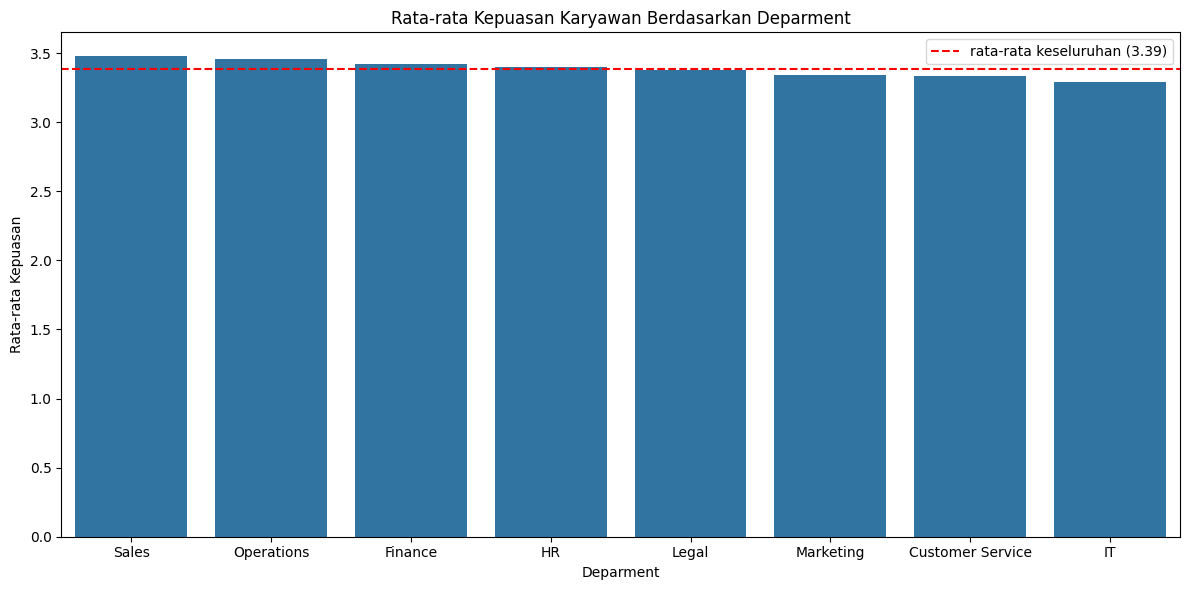

In [12]:
#Visualisasi segment customer per department
plt.figure(figsize=(12,6))
sns.barplot(
    data=hasil,
    x="deparment",
    y="rata_rata_kepuasan"
)

plt.axhline(        #Buat garis horizontal pada nilai rata-rata keseluruhan, warnanya merah, bentuknya putus-putus
    rata_rata,
    color="red",
    linestyle="--",
    label=f"rata-rata keseluruhan ({rata_rata:.2f})"
)

plt.title ("Rata-rata Kepuasan Karyawan Berdasarkan Deparment")
plt.xlabel("Deparment")
plt.ylabel("Rata-rata Kepuasan")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
#Berdasarkan usia
usia = satisfaction_people.groupby("age")["job_satisfaction"].mean().sort_values(ascending=False)

#Berdasarkan matrial status
marital_status = satisfaction_people.groupby("marital_status")["job_satisfaction"].mean().sort_values(ascending=False)

#Berdasarkan pengalaman
experience = satisfaction_people.groupby("experience")["job_satisfaction"].mean().sort_values(ascending=False)

#Bedasarkan Beban kerja yang diterima karyawan
workload = satisfaction_people.groupby("workload")["job_satisfaction"].mean().sort_values(ascending=False)

#Berdasrkan work life balance
wlb = satisfaction_people.groupby("wlb")["job_satisfaction"].mean().sort_values(ascending=False)

#Berdasarkan work environment
work_env = satisfaction_people.groupby("work_env")["job_satisfaction"].mean().sort_values(ascending=False)

#Berdasarkan education
edu = satisfaction_people.groupby("edu_level")["job_satisfaction"].mean().sort_values(ascending=False)

print(f"Berdasarkan usia: \n{usia}")
print(f"Berdasarkan marital status: \n{marital_status}")
print(f"Berdasarkan pengalaman: \n{experience}")
print(f"Berdasarkan workload: \n{workload}")
print(f"Berdasarkan work life balance : \n{wlb}")
print(f"Berdasarkan work evironment: \n{work_env}")
print(f'Berdasarkan education: \n{edu}')

Berdasarkan usia: 
age
58    3.818182
49    3.651163
47    3.600000
37    3.596154
31    3.538462
27    3.533333
24    3.531034
40    3.525773
50    3.518519
29    3.485149
34    3.484211
45    3.478261
46    3.475000
51    3.446809
32    3.432990
41    3.425000
60    3.421053
43    3.414634
26    3.410000
30    3.404040
35    3.391304
39    3.364706
23    3.337748
28    3.317308
38    3.304878
44    3.302326
22    3.286713
54    3.277778
25    3.277228
53    3.258621
48    3.232143
52    3.212766
56    3.157895
42    3.142857
59    3.115385
36    3.081081
33    3.074468
55    3.000000
57    2.750000
Name: job_satisfaction, dtype: float64
Berdasarkan marital status: 
marital_status
Divorced    3.523810
Single      3.424576
Married     3.324266
Name: job_satisfaction, dtype: float64
Berdasarkan pengalaman: 
experience
27    4.150000
25    3.689655
5     3.510490
7     3.500000
2     3.472340
13    3.460784
18    3.456140
16    3.450000
8     3.429688
15    3.428571
3     3.420455
10    

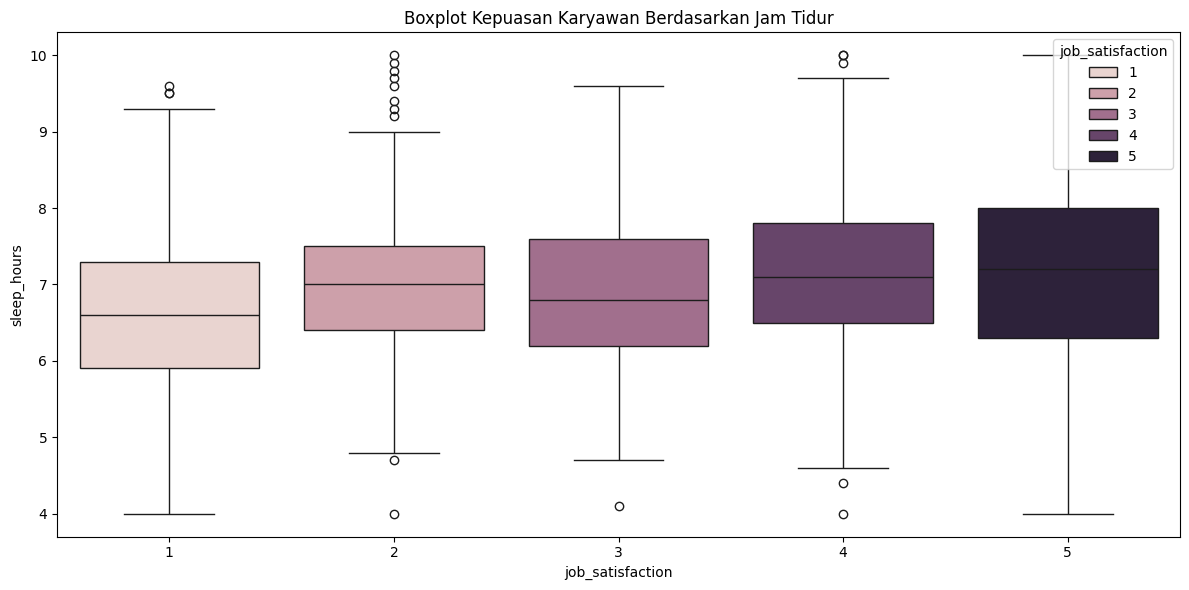

In [19]:
#Job satisfaction by sleep hours
plt.figure(figsize=(12,6))
sns.boxplot(data = satisfaction_people,
             x = 'job_satisfaction',
             y = 'sleep_hours',
             hue = 'job_satisfaction')
plt.title("Boxplot Kepuasan Karyawan Berdasarkan Jam Tidur")
plt.tight_layout()
plt.show()

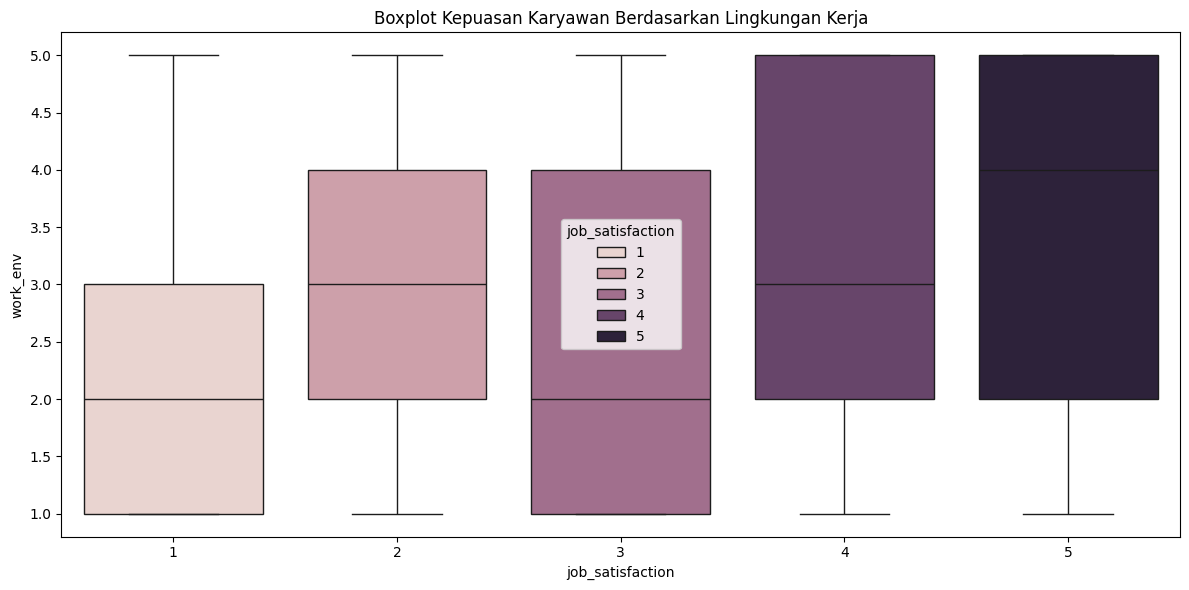

In [24]:
# Job satisfaction by work enviroment
plt.figure(figsize=(12,6))
sns.boxplot(data = satisfaction_people,
             x = 'job_satisfaction',
             y = 'work_env',
             hue = 'job_satisfaction')
plt.title("Boxplot Kepuasan Karyawan Berdasarkan Lingkungan Kerja")
plt.tight_layout()
plt.show()

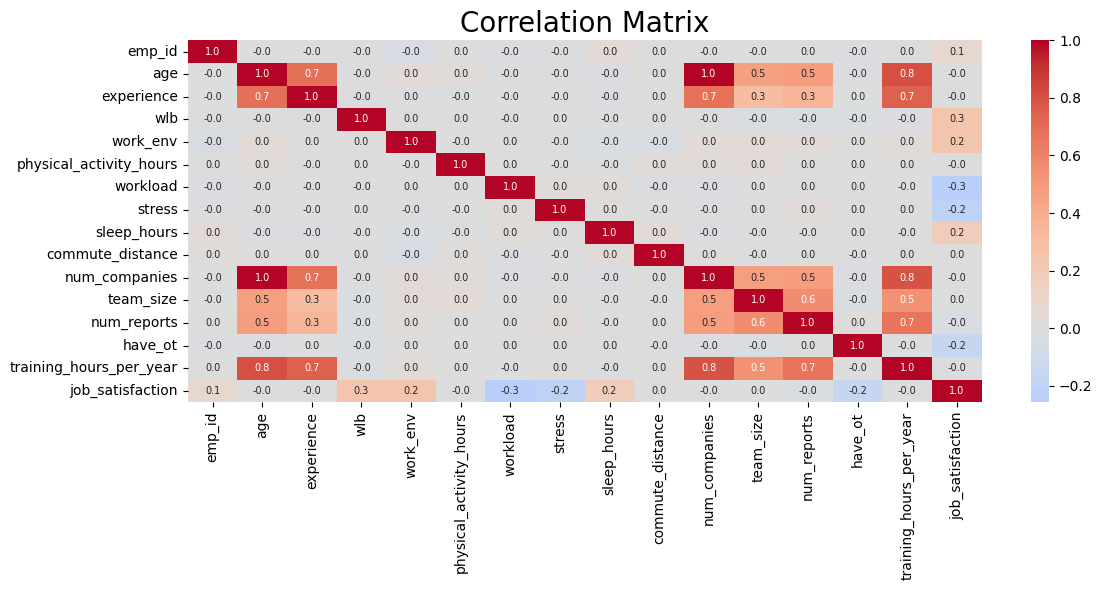

Angka korelasi berada antara -1 sampai +1:
+1 → hubungan positif sangat kuat
+0.7 → hubungan positif kuat
0 → hampir tidak ada hubungan linear
-0.7 → hubungan negatif kuat
-1 → hubungan negatif sempurna


In [27]:

corr_matrix =people.select_dtypes(exclude='object').corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center = 0,
            fmt = ".1f",
            annot = True,
            annot_kws={"size":7})

plt.title("Correlation Matrix", size = 20)
plt.tight_layout()
plt.show()
print(f'Angka korelasi berada antara -1 sampai +1:')
print(f'+1 → hubungan positif sangat kuat')
print(f'+0.7 → hubungan positif kuat')
print(f'0 → hampir tidak ada hubungan linear')
print(f'-0.7 → hubungan negatif kuat')
print(f'-1 → hubungan negatif sempurna')